# STO-DA Step 1 — Monte Carlo Scenario Generation and Backward Reduction Algorithm (BRA)

This notebook prepares the uncertainty scenarios for the two-stage stochastic day-ahead model.

### Goals

- Generate 24-h normalized Gaussian forecast-error trajectories for PV, wind, and load.
- Check initial Monte Carlo pool stability for \(N_0\in\{500,1000,2000,5000\}\).
- Use a main pool of \(N_0=5000\) after the stability check.
- Apply a probability-preserving **Backward Reduction Algorithm (BRA)**.
- Capture exact BRA snapshots at \(|S_r|\in\{50,30,20,10,5\}\) in **one continuous reduction run**.
- Save retained normalized error trajectories and probabilities for the next Pyomo STO-DA notebook.

The final retained scenario count is **not** selected here. It will be selected later using STO-DA **OOS cost versus computation time**.

In [1]:
# Run only if these packages are missing.
%pip install -q pandas numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import heapq
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

ROOT = Path.cwd()

def find_file(filename):
    candidates = [
        ROOT / filename,
        ROOT / 'data' / filename,
        ROOT / 'config' / filename,
        Path('/mnt/data') / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f'Could not locate {filename}. Tried: {candidates}')

DEV_FILE = find_file('rye_development_304days.csv')
try:
    PARAM_FILE = find_file('study_parameters_frozen_v2.json')
except FileNotFoundError:
    PARAM_FILE = find_file('study_parameters_frozen_v1.json')

dev = pd.read_csv(DEV_FILE)
with open(PARAM_FILE, 'r', encoding='utf-8') as f:
    CFG = json.load(f)

print('Development data:', DEV_FILE)
print('Parameters:', PARAM_FILE)
print('Development days:', dev['date_utc'].nunique())

Development data: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Pyomo\rye_development_304days.csv
Parameters: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Pyomo\study_parameters_frozen_v2.json
Development days: 304


## 1. Scenario protocol

For \(X\in\{PV,W,L\}\), the controlled scenario error is

\[
e^X_{t,s}\sim\mathcal N(0,\alpha^2),
\qquad
\alpha\in\{0.05,0.10,0.20,0.30\}.
\]

A scenario contains 24 hourly errors for each uncertain source. For reduction, the distance vector is

\[
\mathbf e_s=[e^{PV}_{1:24,s},e^W_{1:24,s},e^L_{1:24,s}],
\]

which is 72-dimensional. Using normalized error space prevents the source with the largest kW scale from dominating the distance metric.

Because the same normalized uncertainty law is used across days, the **reduced error scenarios can later be reused across all OOS days for a given \(\alpha\)** and then mapped to each day's point forecast.

In [3]:
T = CFG['time']['T_hours']
PV_RATED = CFG['rye_physical_system']['pv_rated_kwp']
WIND_RATED = CFG['rye_physical_system']['wind_rated_kw']
ALPHAS = CFG['uncertainty']['alpha_levels']
MAIN_N0 = CFG['uncertainty'].get('initial_monte_carlo_scenarios', 5000)
POOL_SIZES = CFG['uncertainty'].get('initial_pool_sensitivity', [500,1000,2000,5000])
REDUCED_COUNTS = sorted(CFG['uncertainty']['reduced_scenario_candidates'])
BASE_SEED = CFG['uncertainty']['random_seed']
SENSITIVITY_ALPHA = CFG['uncertainty'].get('pool_sensitivity_alpha', 0.20)

print('Main N0:', MAIN_N0)
print('Pool sensitivity:', POOL_SIZES)
print('Reduced scenario candidates:', REDUCED_COUNTS)
print('Alpha levels:', ALPHAS)

Main N0: 5000
Pool sensitivity: [500, 1000, 2000, 5000]
Reduced scenario candidates: [5, 10, 20, 30, 50]
Alpha levels: [0.05, 0.1, 0.2, 0.3]


In [4]:
def stable_seed(*parts, base=BASE_SEED):
    value = int(base)
    for p in parts:
        for ch in str(p):
            value = (value * 131 + ord(ch)) % (2**32 - 1)
    return value


def generate_error_pool(alpha, n_scenarios, seed):
    # Generate N x 72 normalized forecast-error trajectories.
    rng = np.random.default_rng(seed)
    e_pv = rng.normal(0.0, alpha, size=(n_scenarios, 24))
    e_w  = rng.normal(0.0, alpha, size=(n_scenarios, 24))
    e_l  = rng.normal(0.0, alpha, size=(n_scenarios, 24))
    errors = np.concatenate([e_pv, e_w, e_l], axis=1).astype(np.float32)
    probs = np.full(n_scenarios, 1.0/n_scenarios, dtype=np.float64)
    return errors, probs


def apply_errors_to_forecast(point_forecast, errors):
    # Map normalized errors to physical PV/wind/load scenario trajectories.
    e_pv, e_w, e_l = errors[:,0:24], errors[:,24:48], errors[:,48:72]
    pv0 = np.asarray(point_forecast['pv_forecast'], dtype=float)[None,:]
    w0  = np.asarray(point_forecast['wind_forecast'], dtype=float)[None,:]
    l0  = np.asarray(point_forecast['load_forecast'], dtype=float)[None,:]
    pv = np.clip(pv0 * (1.0 + e_pv), 0.0, PV_RATED)
    wind = np.clip(w0 * (1.0 + e_w), 0.0, WIND_RATED)
    load = np.maximum(l0 * (1.0 + e_l), 0.0)
    return {'pv': pv.astype(np.float32), 'wind': wind.astype(np.float32), 'load': load.astype(np.float32)}

## 2. Initial Monte Carlo pool-size sensitivity

A single 5000-scenario master draw is generated at \(\alpha=20\%\). The first 500, 1000, 2000, and 5000 samples are compared so the sample-size effect is not confounded by unrelated random seeds.

For each source, inspect empirical mean, standard deviation, 5th/50th/95th percentiles, and deviation from the target \(\alpha\).

In [5]:
master_errors, master_probs = generate_error_pool(
    alpha=SENSITIVITY_ALPHA,
    n_scenarios=max(POOL_SIZES),
    seed=stable_seed('pool_sensitivity', SENSITIVITY_ALPHA),
)

def source_stats(errors, N0, alpha):
    e = errors[:N0]
    blocks = {'PV': e[:,0:24].ravel(), 'Wind': e[:,24:48].ravel(), 'Load': e[:,48:72].ravel()}
    rows=[]
    for src, v in blocks.items():
        std = v.std(ddof=1)
        rows.append({'N0':N0, 'source':src, 'mean_error':v.mean(), 'std_error':std,
                     'target_alpha':alpha, 'abs_std_deviation':abs(std-alpha),
                     'q05':np.quantile(v,0.05), 'q50':np.quantile(v,0.50), 'q95':np.quantile(v,0.95)})
    return rows

rows=[]
for N0 in POOL_SIZES:
    rows.extend(source_stats(master_errors, N0, SENSITIVITY_ALPHA))
pool_stats = pd.DataFrame(rows)
display(pool_stats)

pool_summary = (pool_stats.groupby('N0')
    .agg(max_abs_mean_error=('mean_error', lambda x: np.max(np.abs(x))),
         max_abs_std_deviation=('abs_std_deviation','max')).reset_index())
display(pool_summary)

,N0,source,mean_error,std_error,target_alpha,abs_std_deviation,q05,q50,q95
0,500,PV,-0.002834,0.199959,0.2,0.000041,-0.335861,-0.000943,0.323251
1,500,Wind,-0.003037,0.199433,0.2,0.000567,-0.336936,-0.000824,0.320398
2,500,Load,0.002292,0.199929,0.2,0.000071,-0.324091,0.000120,0.332864
3,1000,PV,-0.000646,0.200036,0.2,0.000036,-0.330764,0.000146,0.328869
4,1000,Wind,-0.001797,0.199062,0.2,0.000938,-0.330471,-0.001568,0.324953
5,1000,Load,0.000636,0.199274,0.2,0.000726,-0.326833,0.000294,0.328413
6,2000,PV,0.000279,0.199863,0.2,0.000137,-0.327932,0.001332,0.329266
7,2000,Wind,-0.000734,0.199147,0.2,0.000853,-0.327846,-0.000421,0.327069
8,2000,Load,-0.000026,0.199681,0.2,0.000319,-0.326519,-0.000441,0.329269
9,5000,PV,0.000343,0.199734,0.2,0.000266,-0.328503,0.001066,0.328546


,N0,max_abs_mean_error,max_abs_std_deviation
0,500,0.003037,0.000567
1,1000,0.001797,0.000938
2,2000,0.000734,0.000853
3,5000,0.000343,0.000578


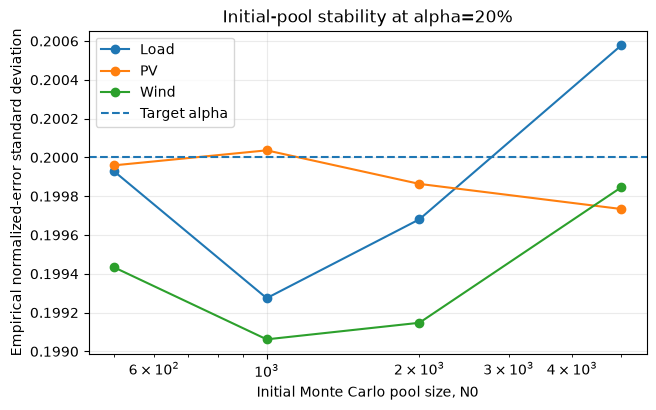

In [6]:
fig, ax = plt.subplots(figsize=(7.2,4.2))
for source, g in pool_stats.groupby('source'):
    ax.plot(g['N0'], g['std_error'], marker='o', label=source)
ax.axhline(SENSITIVITY_ALPHA, linestyle='--', label='Target alpha')
ax.set_xscale('log')
ax.set_xlabel('Initial Monte Carlo pool size, N0')
ax.set_ylabel('Empirical normalized-error standard deviation')
ax.set_title(f'Initial-pool stability at alpha={SENSITIVITY_ALPHA:.0%}')
ax.grid(alpha=0.25); ax.legend(); plt.show()

## 3. Backward Reduction Algorithm

For each active scenario \(i\), find its nearest active neighbor \(j\) and compute
\[
\Delta_i=\pi_i d(i,j).
\]
The scenario with the smallest deletion impact is removed and its probability is transferred to its nearest retained neighbor:
\[
\pi_j\leftarrow\pi_j+\pi_i.
\]
The process continues to 5 scenarios, with exact snapshots captured at 50, 30, 20, 10, and 5. The pairwise distance matrix is computed once and a lazy priority queue is used.

In [7]:
def backward_reduction_snapshots(errors, probabilities, targets=(5,10,20,30,50), verbose=True):
    errors = np.asarray(errors, dtype=np.float32)
    probs = np.asarray(probabilities, dtype=np.float64).copy()
    targets = sorted(set(int(k) for k in targets))
    min_target = min(targets)
    n = len(probs)
    if min_target < 2 or max(targets) >= n:
        raise ValueError('Require 2 <= min(targets) and max(targets) < N.')

    t0 = time.perf_counter()
    print(f'Computing {n}x{n} pairwise distance matrix...')
    D = cdist(errors, errors, metric='euclidean').astype(np.float32)
    np.fill_diagonal(D, np.inf)
    print(f'Distance matrix ready in {time.perf_counter()-t0:.1f} s; size={D.nbytes/1e6:.1f} MB')

    active = np.ones(n, dtype=bool)
    version = np.zeros(n, dtype=np.int64)

    def nearest_active(i):
        work = D[i].copy()
        work[~active] = np.inf
        work[i] = np.inf
        j = int(np.argmin(work))
        return j, float(work[j])

    heap=[]
    for i in range(n):
        j,d = nearest_active(i)
        heapq.heappush(heap, (probs[i]*d, i, version[i]))

    snapshots={}; history=[]; remaining=n; deleted=0
    while remaining > min_target:
        while True:
            old_cost, i, ver = heapq.heappop(heap)
            if not active[i] or ver != version[i]:
                continue
            j,d = nearest_active(i)
            true_cost = probs[i]*d
            if true_cost > old_cost + 1e-12:
                version[i] += 1
                heapq.heappush(heap, (true_cost, i, version[i]))
                continue
            break

        p_removed = probs[i]
        active[i] = False; probs[i] = 0.0; remaining -= 1; deleted += 1
        probs[j] += p_removed
        version[j] += 1
        if remaining > 1:
            j2,d2 = nearest_active(j)
            heapq.heappush(heap, (probs[j]*d2, j, version[j]))

        if remaining in targets:
            idx=np.where(active)[0].copy(); pr=probs[idx].copy(); pr/=pr.sum()
            snapshots[remaining]={'idx':idx,'prob':pr}
            print(f'Captured exact BRA snapshot: K={remaining}')

        if verbose and (deleted % 500 == 0 or remaining in targets):
            history.append({'deleted':deleted,'remaining':remaining,'elapsed_s':time.perf_counter()-t0,
                            'probability_sum':probs[active].sum()})
            print(f'Deleted {deleted:4d}; retained {remaining:4d}; elapsed {time.perf_counter()-t0:.1f} s')

    return snapshots, pd.DataFrame(history)

## 4. Quick BRA validation

Run the small 500-scenario test first.

In [8]:
quick_errors = master_errors[:500]
quick_probs = np.full(500,1/500,dtype=float)
quick_targets=(50,30,20,10,5)
quick_sets, quick_history = backward_reduction_snapshots(quick_errors, quick_probs, targets=quick_targets, verbose=True)
for K in quick_targets:
    assert K in quick_sets
    assert len(quick_sets[K]['idx']) == K
    assert np.isclose(quick_sets[K]['prob'].sum(),1.0,atol=1e-10)
    assert (quick_sets[K]['prob']>0).all()
print('BRA quick validation PASSED.')

Computing 500x500 pairwise distance matrix...
Distance matrix ready in 0.0 s; size=1.0 MB
Captured exact BRA snapshot: K=50
Deleted  450; retained   50; elapsed 0.0 s
Captured exact BRA snapshot: K=30
Deleted  470; retained   30; elapsed 0.0 s
Captured exact BRA snapshot: K=20
Deleted  480; retained   20; elapsed 0.0 s
Captured exact BRA snapshot: K=10
Deleted  490; retained   10; elapsed 0.0 s
Captured exact BRA snapshot: K=5
Deleted  495; retained    5; elapsed 0.0 s
BRA quick validation PASSED.


## 5. Main 5000-scenario BRA run

Only run this after the quick validation passes. The 5000×5000 float32 distance matrix is about **100 MB**.

In [9]:
main_errors, main_probs = generate_error_pool(alpha=SENSITIVITY_ALPHA, n_scenarios=MAIN_N0,
                                              seed=stable_seed('main_BRA', SENSITIVITY_ALPHA))
bra_sets, bra_history = backward_reduction_snapshots(main_errors, main_probs, targets=REDUCED_COUNTS, verbose=True)
for K in REDUCED_COUNTS:
    assert len(bra_sets[K]['idx']) == K
    assert np.isclose(bra_sets[K]['prob'].sum(),1.0,atol=1e-10)
print('Main BRA run PASSED.')

Computing 5000x5000 pairwise distance matrix...
Distance matrix ready in 1.0 s; size=100.0 MB
Deleted  500; retained 4500; elapsed 1.1 s
Deleted 1000; retained 4000; elapsed 1.1 s
Deleted 1500; retained 3500; elapsed 1.1 s
Deleted 2000; retained 3000; elapsed 1.2 s
Deleted 2500; retained 2500; elapsed 1.2 s
Deleted 3000; retained 2000; elapsed 1.2 s
Deleted 3500; retained 1500; elapsed 1.3 s
Deleted 4000; retained 1000; elapsed 1.3 s
Deleted 4500; retained  500; elapsed 1.3 s
Captured exact BRA snapshot: K=50
Deleted 4950; retained   50; elapsed 1.3 s
Captured exact BRA snapshot: K=30
Deleted 4970; retained   30; elapsed 1.3 s
Captured exact BRA snapshot: K=20
Deleted 4980; retained   20; elapsed 1.3 s
Captured exact BRA snapshot: K=10
Deleted 4990; retained   10; elapsed 1.3 s
Captured exact BRA snapshot: K=5
Deleted 4995; retained    5; elapsed 1.3 s
Main BRA run PASSED.


## 6. Reduction-quality diagnostics

Compare full-pool moments with probability-weighted reduced-set moments.

In [10]:
def weighted_mean_std(X,w):
    w=np.asarray(w,dtype=float); w=w/w.sum()
    mu=np.sum(X*w[:,None],axis=0)
    var=np.sum(((X-mu)**2)*w[:,None],axis=0)
    return mu,np.sqrt(var)

full_mu=main_errors.mean(axis=0); full_sd=main_errors.std(axis=0,ddof=0)
quality_rows=[]
for K in REDUCED_COUNTS:
    idx=bra_sets[K]['idx']; prob=bra_sets[K]['prob']; mu,sd=weighted_mean_std(main_errors[idx],prob)
    quality_rows.append({'K':K,'max_abs_mean_difference':np.max(np.abs(mu-full_mu)),
                         'mean_abs_mean_difference':np.mean(np.abs(mu-full_mu)),
                         'max_abs_std_difference':np.max(np.abs(sd-full_sd)),
                         'mean_abs_std_difference':np.mean(np.abs(sd-full_sd)),
                         'probability_sum':prob.sum()})
quality=pd.DataFrame(quality_rows).sort_values('K'); display(quality)

,K,max_abs_mean_difference,mean_abs_mean_difference,max_abs_std_difference,mean_abs_std_difference,probability_sum
0,5,0.184836,0.054011,0.158995,0.073110,1.0
1,10,0.162913,0.035532,0.141573,0.059249,1.0
2,20,0.082729,0.027922,0.107376,0.050444,1.0
3,30,0.052889,0.021773,0.088357,0.047429,1.0
4,50,0.051215,0.018303,0.082623,0.044006,1.0


## 7. Save candidate reduced error sets

These normalized errors and probabilities will be direct inputs to the next STO-DA notebook.

In [11]:
OUT_DIR=Path('bra_outputs'); OUT_DIR.mkdir(exist_ok=True)
for K in REDUCED_COUNTS:
    idx=bra_sets[K]['idx']; prob=bra_sets[K]['prob']
    path=OUT_DIR/f'bra_alpha{int(SENSITIVITY_ALPHA*100):02d}_N{MAIN_N0}_K{K}.npz'
    np.savez_compressed(path, errors=main_errors[idx], probability=prob, original_index=idx,
                        alpha=SENSITIVITY_ALPHA, N0=MAIN_N0, K=K)
    print('Saved:',path)
pool_stats.to_csv(OUT_DIR/'N0_pool_sensitivity.csv',index=False)
pool_summary.to_csv(OUT_DIR/'N0_pool_summary.csv',index=False)
quality.to_csv(OUT_DIR/'BRA_distribution_quality.csv',index=False)
bra_history.to_csv(OUT_DIR/'BRA_runtime_history.csv',index=False)
print('All scenario-preparation outputs saved.')

Saved: bra_outputs\bra_alpha20_N5000_K5.npz
Saved: bra_outputs\bra_alpha20_N5000_K10.npz
Saved: bra_outputs\bra_alpha20_N5000_K20.npz
Saved: bra_outputs\bra_alpha20_N5000_K30.npz
Saved: bra_outputs\bra_alpha20_N5000_K50.npz
All scenario-preparation outputs saved.


## 8. Next step

After the pool-sensitivity and BRA-quality tables are checked, the next notebook will implement the **two-stage STO-DA Pyomo MILP** and evaluate \(K=5,10,20,30,50\) using common held-out OOS days. The final \(K\) will be selected from **OOS operating cost versus computation time**, not from scenario statistics alone.